In [2]:
import numpy as np
import pandas as pd

from plotly.subplots import make_subplots

from pychemelt import Monomer
from pychemelt.utils.plotting import *

import plotly.graph_objs as go

import sys
sys.path.append('../')
from scripts import display_figure_static, set_condition_indexes_to_false

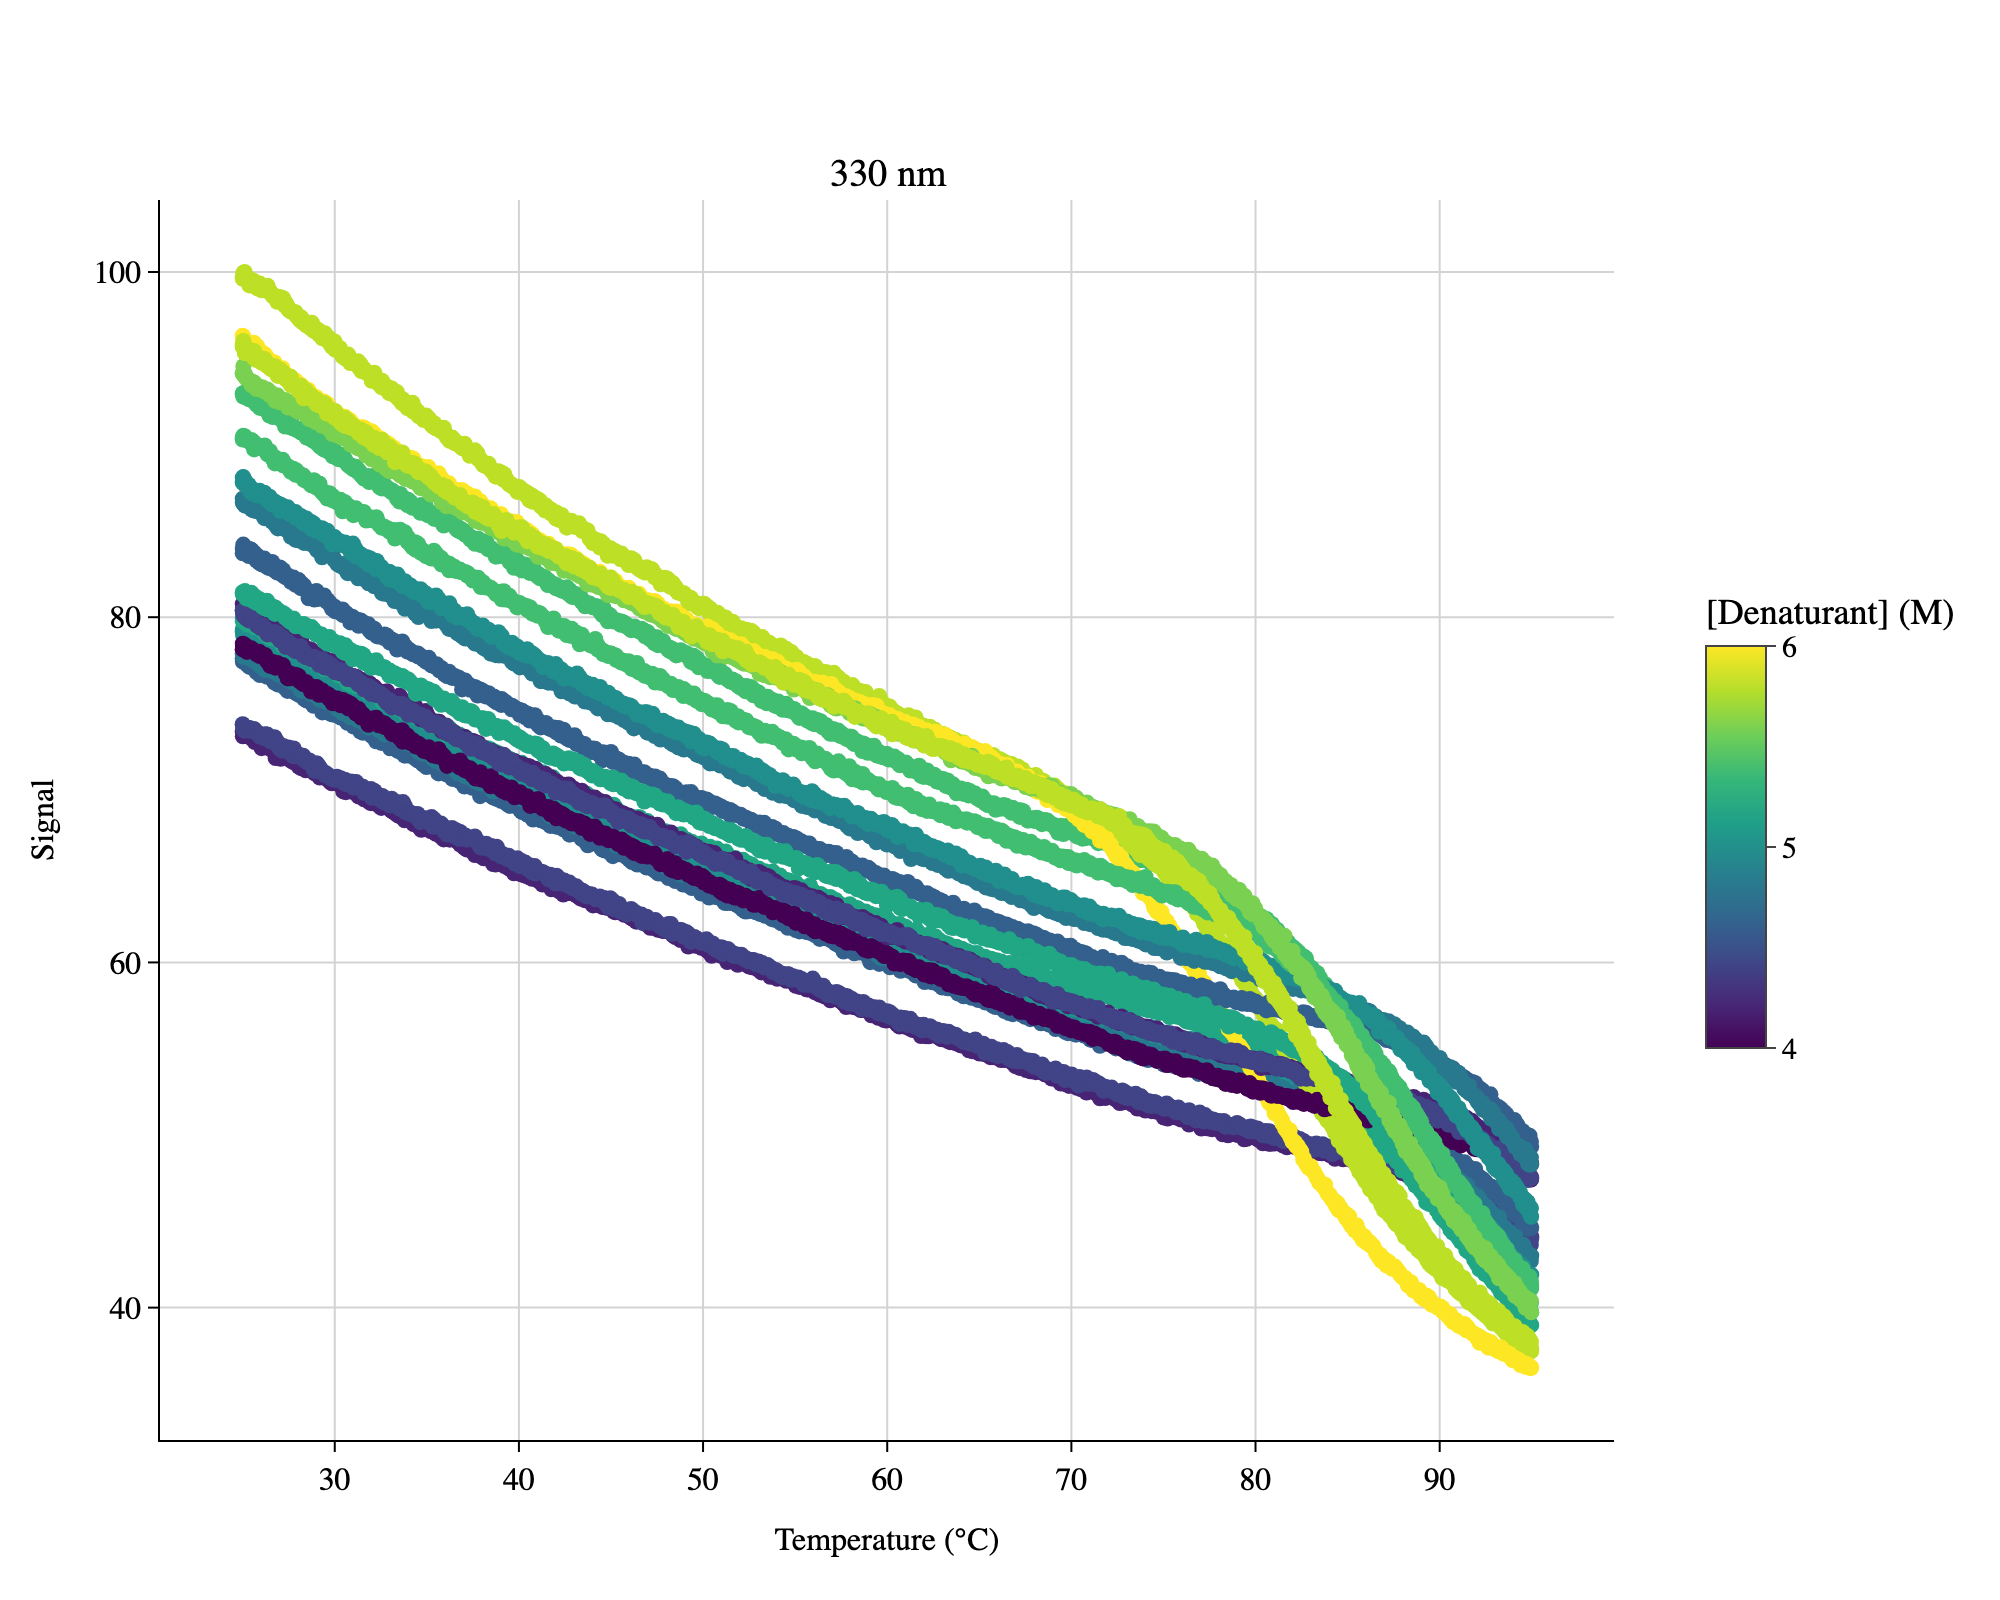

In [3]:
INDEX = 5
NAME = "P6A" # Name used in the manuscript

# creating a Sample object for the storage and processing of the DSF data
sample = Monomer()

# reading the data
sample.read_file(f'../../data/titer1.xlsx')

sample.set_denaturant_concentrations()

# Selecting conditions
sample.set_signal(['330 nm'])#, '350 nm'])

conditions = [True]*44
# Index of the curves to be excluded from the analysis, starting from 1
outliers_or_other_data = ["1-23","31","44"] 

conditions = set_condition_indexes_to_false(conditions,outliers_or_other_data)

#using all curves except the curve without denaturant as in the paper
sample.select_conditions(conditions,normalise_to_global_max=True)

plot_config = PlotConfig()
plot_config.font_size = 24

legend_config = LegendConfig()
legend_config.color_bar_orientation = "h"
legend_config.color_bar_length = 0.6
legend_config.color_bar_x_pos = 0.7
legend_config.color_bar_y_pos = 0.9

#Plotting the selected signals against the temperature
fig = plot_unfolding(sample,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

In [4]:
# Reducing the amount of data and preprocessing steps for a faster analysis
sample.pre_fit = False
sample.max_points = 200

sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
    native_baseline_type='exponential',
    unfolded_baseline_type='linear',
)

# estimations of parameters
sample.estimate_derivative()
sample.guess_Tm()

# All local fit for parameter estimation
sample.fit_thermal_unfolding_local()

# Setting the number of residues of the protein for an initial estiamte of the Cp value
# We use a lower value than expected because of the hyperstability.
sample.n_residues = 60 
sample.guess_Cp()

sample.set_signal_id()

sample.compare_models(
    native_baseline_types=['linear','quadratic','exponential'],
    # The unfolded baseline is clearly not well defined
    unfolded_baseline_types=['constant','linear'],#,'quadratic','exponential'], 
    global_model_types=['global_global_global'],
    neff=None
)



In [5]:
print(sample.comparison_df)
# add sample name to the comparison dataframe - first column
sample.comparison_df.insert(0, 'Sample', NAME)
# Export to csv - use sample name as filename
sample.comparison_df.to_csv(f'./comparison_tables/{INDEX}_{NAME}_comparison.csv', index=False)

#sample.params_df[:4]

  Native Baseline Unfolded Baseline                           Model Type  \
0       quadratic            linear  Global slopes and global intercepts   
1          linear            linear  Global slopes and global intercepts   
2     exponential            linear  Global slopes and global intercepts   
3          linear          constant  Global slopes and global intercepts   
4       quadratic          constant  Global slopes and global intercepts   
5     exponential          constant  Global slopes and global intercepts   

      Tm    ΔHm   ΔCp  m-value      AIC      BIC     EBIC  Reduced χ²  
0  130.3  212.0  2.43     3.17 -3407.46 -3240.52 -2933.50      0.2298  
1  120.0   98.4  1.09     1.51 -1926.87 -1765.68 -1467.42      0.4333  
2  144.0   28.3  0.34     0.55   792.10   959.05  1266.07      1.3863  
3  155.7   37.7  0.22     0.50   974.74  1130.17  1419.61      1.5002  
4  192.0   45.7  0.47     0.50  3533.19  3694.38  3992.65      4.4814  
5  189.0   39.0  0.50     0.50  395

In [11]:
# Replace sample with the best model
best_model = sample.fit_objects[0]

# Estimate error using leave_one_out cross validation
best_model.leave_one_out_cross_validation()

# Save the leave one out results to a csv file
best_model.loo_df.to_csv(f'./leave_one_out_results/{INDEX}_{NAME}_loo.csv', index=False)

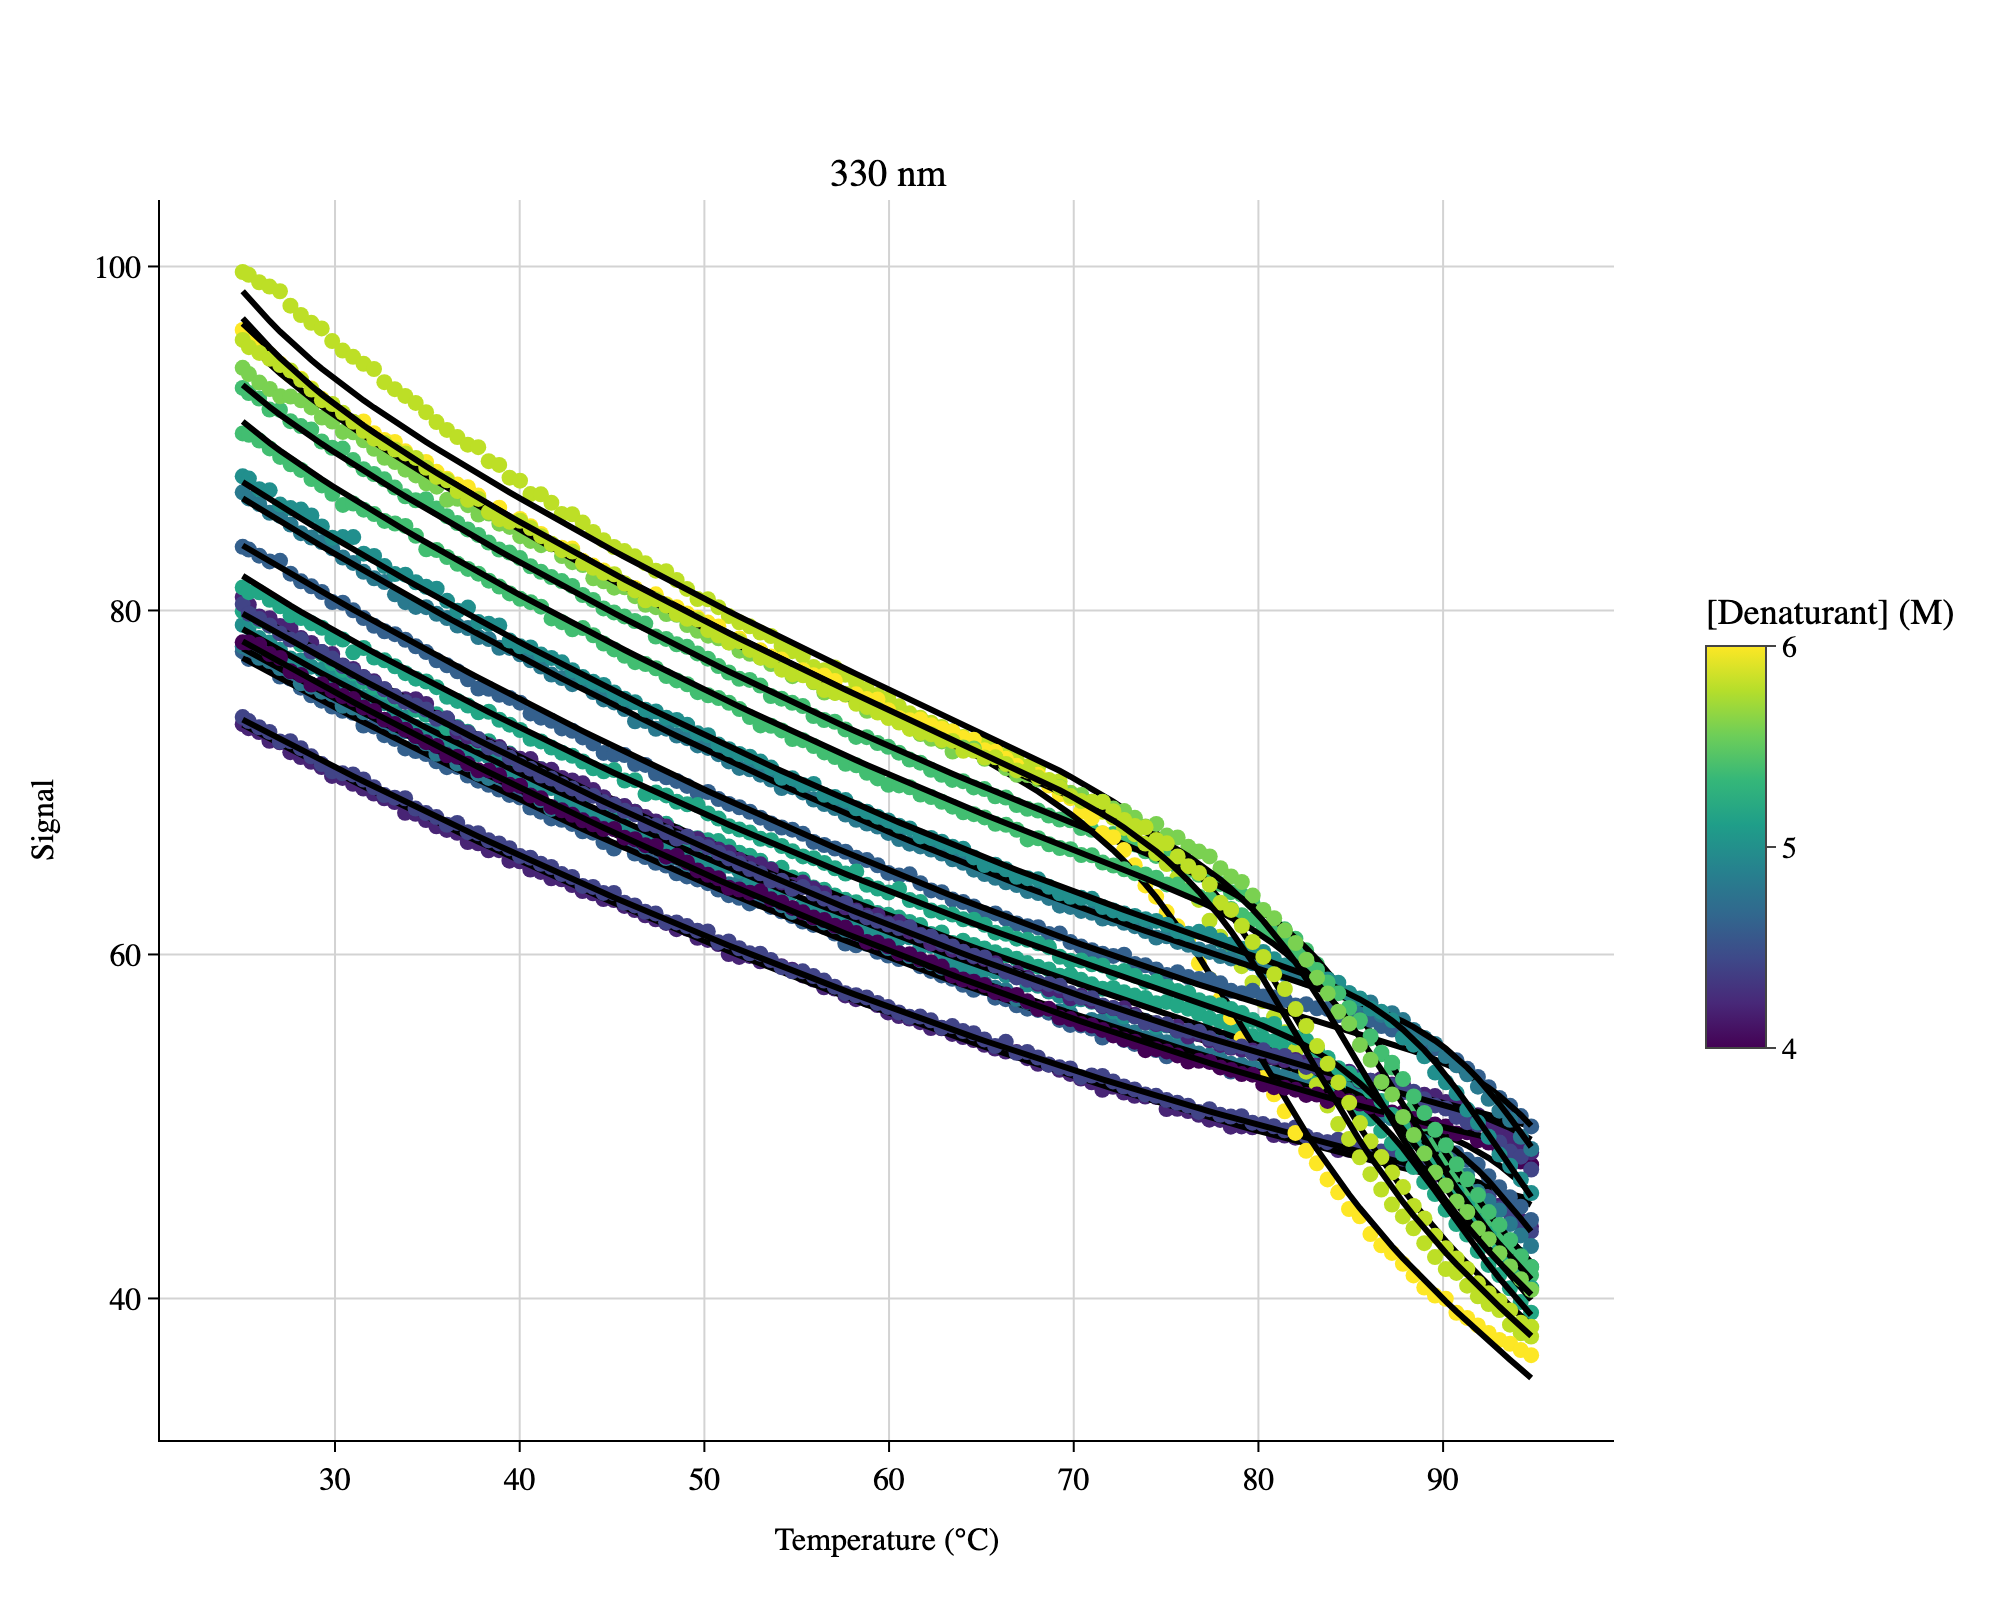

In [8]:
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

here


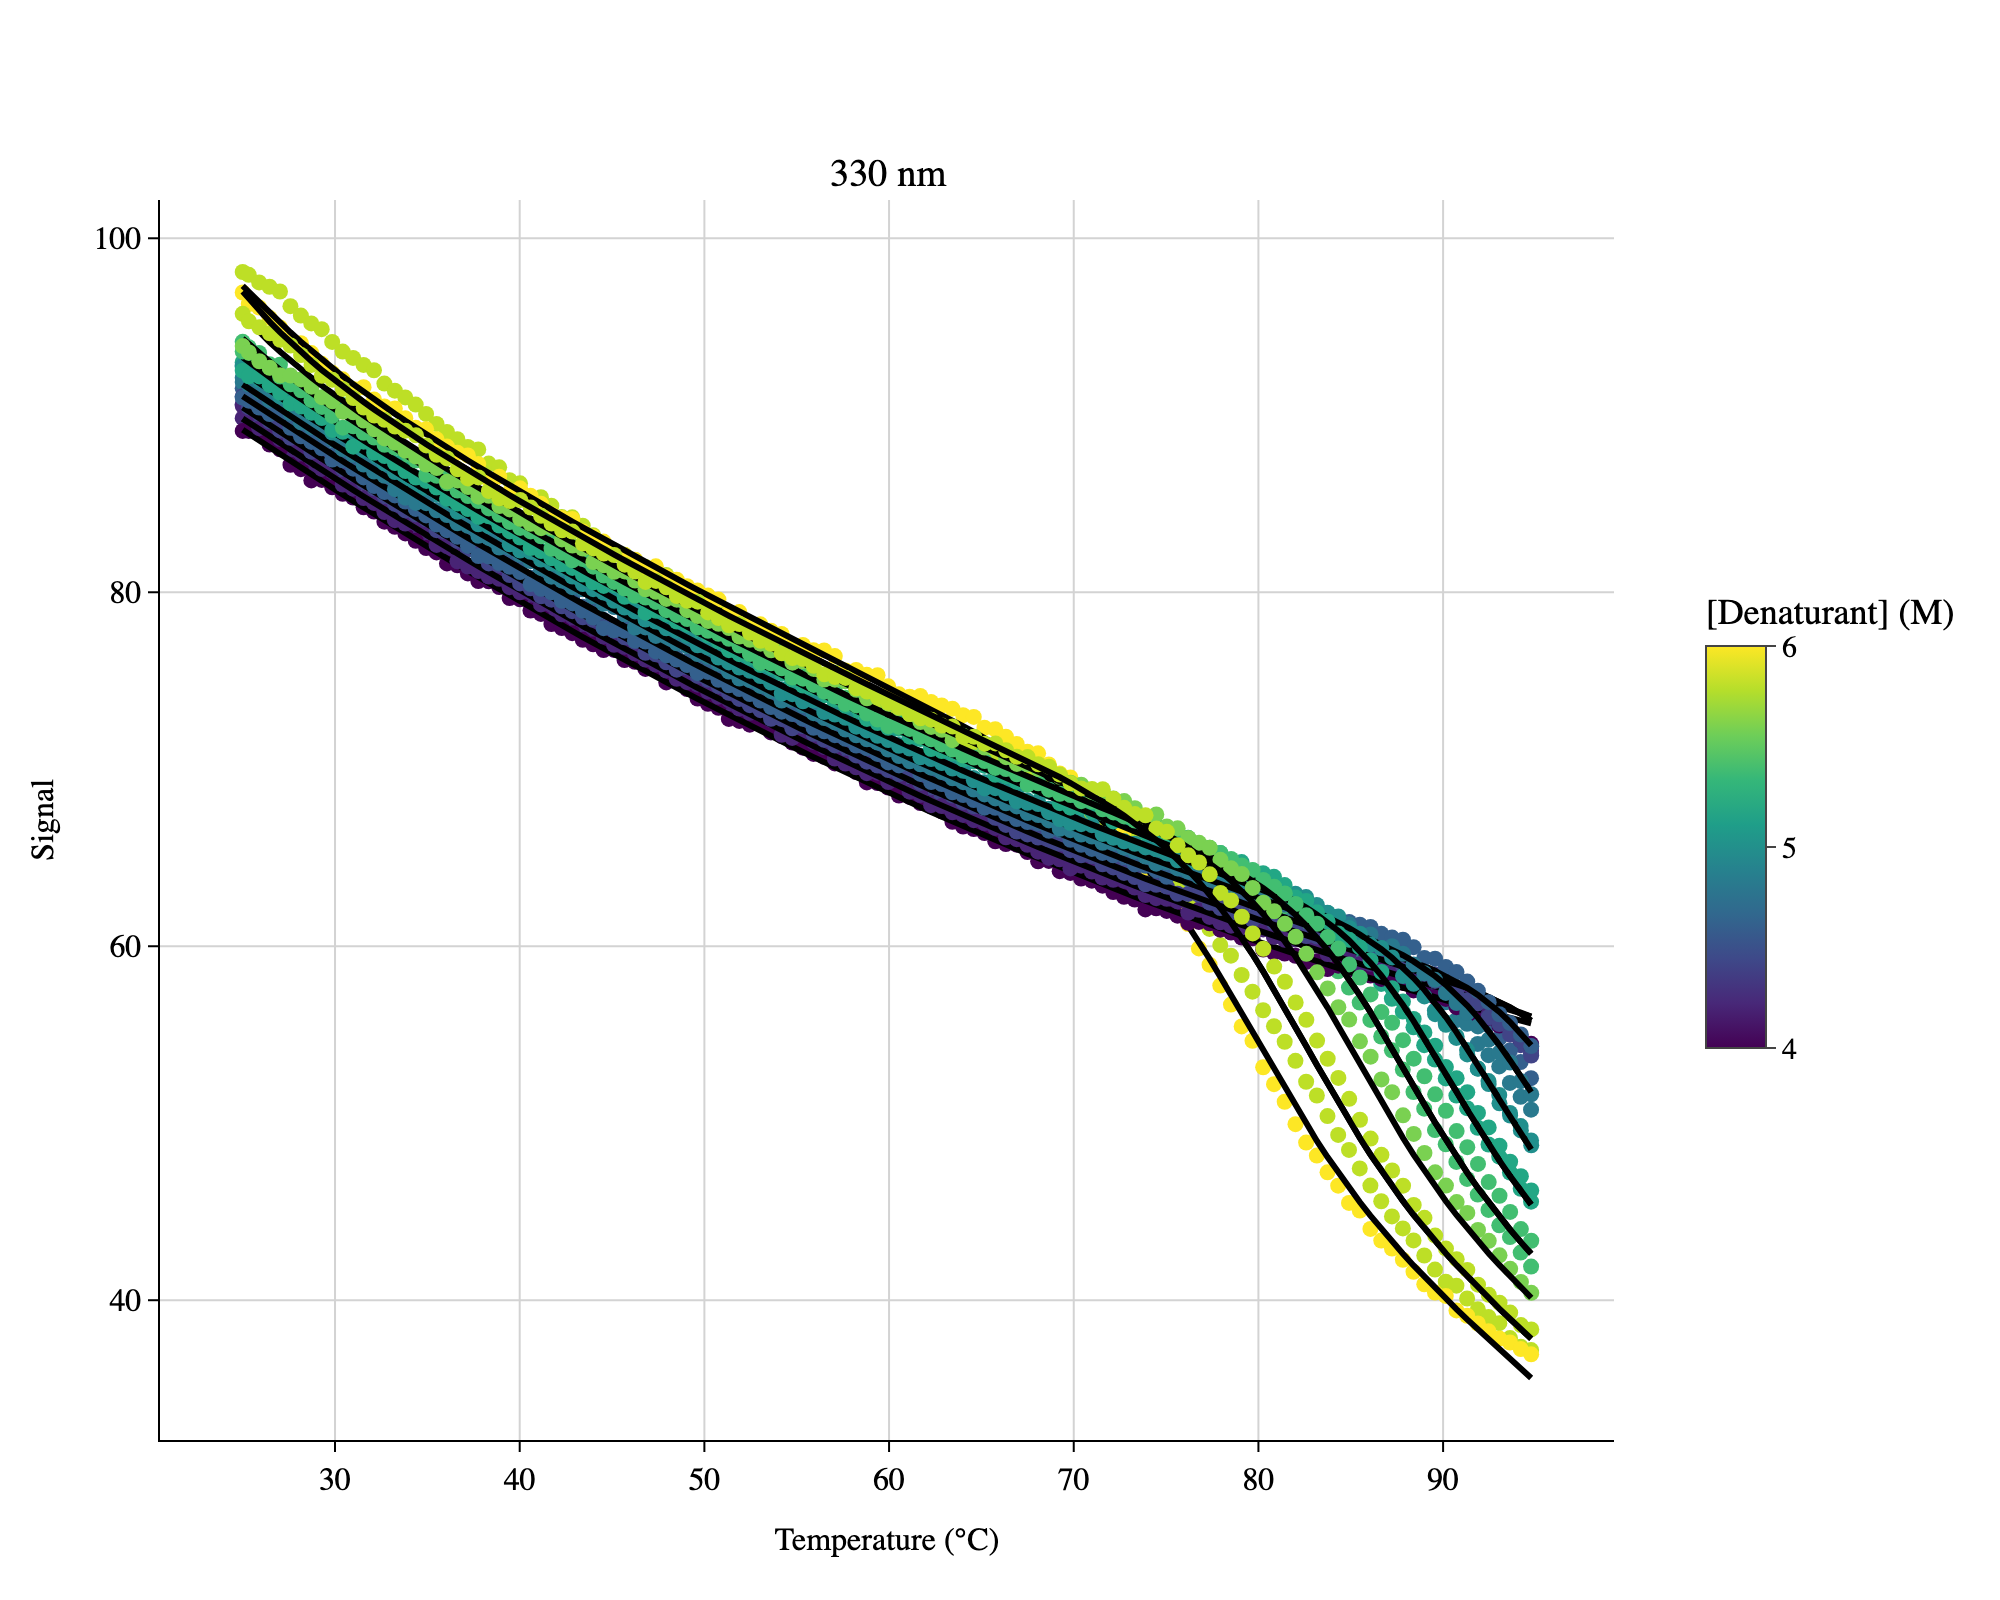

In [ ]:
# Plot the curves taking into account the effect of the scaling factor
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config,use_scaled_data=True)
# save figure
#fig.write_image(f"./figures/{INDEX}_{NAME}_unfolding_curves_fitted_scaled.png")

display_figure_static(fig,height=800, width=1000)